# LeNet

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

net=nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5,padding=2),nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5),nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,stride=2),
    nn.Flatten(),
    nn.Linear(16*5*5,120),nn.ReLU(),
    nn.Linear(120,84),nn.ReLU(),
    nn.Linear(84,10)
)

In [ ]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

In [ ]:
batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size=batch_size)

In [ ]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [ ]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    def init_weight(m):
        if type(m)==nn.Linear or type(m)==nn.Conv2d:
            nn.init.xavier_normal_(m.weight)
    net.apply(init_weight)
    print('training on',device)
    net.to(device)
    loss=nn.CrossEntropyLoss()
    optimizer=torch.optim.SGD(net.parameters(),lr=lr)
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

In [ ]:
lr, num_epochs = 0.05, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

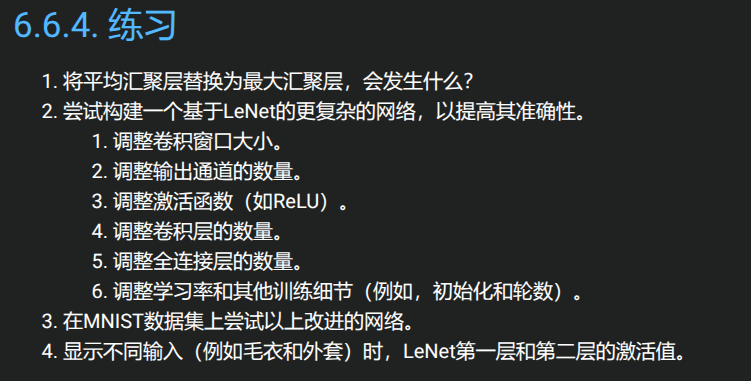

## 模型的优化
一开始不太清楚怎么进行优化整改，经过gpt的指导，我了解了一点。
    首先是卷积层，现在一般使用3*3的卷积，同时可以多堆叠卷积层，使用的数据集是28*28的大小，对个3*3完全可以看到5*5的区域，同时还会注意到更多的细节。
    其次是激活函数，推荐使用ReLU激活函数，这样非线性表达能力更强。
    随后是输出通道数更改，多个输出通道数可以学到更多不同的特征。
    最后我增加了一层全连接层，想法是缓慢递减。

In [24]:
import torch
from torch import nn
from d2l import torch as d2l

net=nn.Sequential(
    nn.Conv2d(1,32,kernel_size=3,padding=2),nn.ReLU(),
    nn.Conv2d(32,32,kernel_size=3,padding=1),nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,stride=2),
    nn.Conv2d(32,64,kernel_size=3),nn.ReLU(),
    nn.Conv2d(64,64,kernel_size=3),nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,stride=2),
    nn.Flatten(),
    nn.Linear(64*5*5,512),nn.ReLU(),
    nn.Linear(512,256),nn.ReLU(),
    nn.Linear(256,128),nn.ReLU(),
    nn.Linear(128,10)
)

In [25]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 32, 30, 30])
ReLU output shape: 	 torch.Size([1, 32, 30, 30])
Conv2d output shape: 	 torch.Size([1, 32, 30, 30])
ReLU output shape: 	 torch.Size([1, 32, 30, 30])
MaxPool2d output shape: 	 torch.Size([1, 32, 15, 15])
Conv2d output shape: 	 torch.Size([1, 64, 13, 13])
ReLU output shape: 	 torch.Size([1, 64, 13, 13])
Conv2d output shape: 	 torch.Size([1, 64, 11, 11])
ReLU output shape: 	 torch.Size([1, 64, 11, 11])
MaxPool2d output shape: 	 torch.Size([1, 64, 5, 5])
Flatten output shape: 	 torch.Size([1, 1600])
Linear output shape: 	 torch.Size([1, 512])
ReLU output shape: 	 torch.Size([1, 512])
Linear output shape: 	 torch.Size([1, 256])
ReLU output shape: 	 torch.Size([1, 256])
Linear output shape: 	 torch.Size([1, 128])
ReLU output shape: 	 torch.Size([1, 128])
Linear output shape: 	 torch.Size([1, 10])


In [26]:
batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size=batch_size)

In [27]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    def init_weight(m):
        if type(m)==nn.Linear or type(m)==nn.Conv2d:
            nn.init.xavier_normal_(m.weight)
    net.apply(init_weight)
    print('training on',device)
    net.to(device)
    loss=nn.CrossEntropyLoss()
    optimizer=torch.optim.SGD(net.parameters(),lr=lr)
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.186, train acc 0.929, test acc 0.865
23741.0 examples/sec on cuda:0


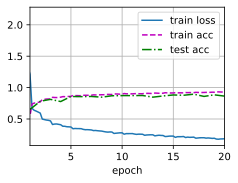

In [28]:
lr, num_epochs = 0.05, 20
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())